# **Trabalho m1.2 - PDI**

**Alunos:** Eduardo Doli Jaques de Oliveira Junior, Miguel Pezzini Kuhr e Nicolas Mendonça Melo Fajardo

**Região do corpo MURA:** Mão

In [15]:
#carregar as bibliotecas
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

np.random.seed(42)  # reprodutibilidade do ruído

In [16]:
#carregar as imagens
caminhos = [
    '/content/image1.png',
    '/content/image2.png',
    '/content/image3.png',
]

imgs_originais = []

for caminho in caminhos:
    img_bgr = cv2.imread(caminho, 1)

    B = img_bgr[:, :, 0].astype(np.float64)
    G = img_bgr[:, :, 1].astype(np.float64)
    R = img_bgr[:, :, 2].astype(np.float64)

    img_cinza = 0.299 * R + 0.587 * G + 0.114 * B
    img_cinza = np.clip(img_cinza, 0, 255).astype(np.uint8)

    imgs_originais.append(img_cinza)

#for img in imgs_originais:
#    cv2_imshow(img)


# Caracterização inicial:

Imagem 1: "analise da imagem 1"


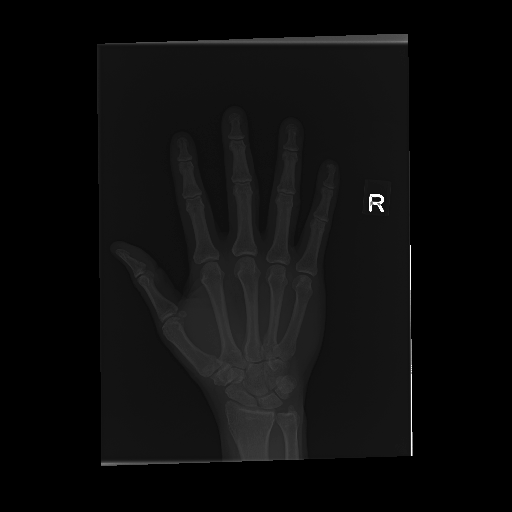

In [17]:
cv2_imshow(imgs_originais[0])

Imagem 2: "analise da imagem 3"

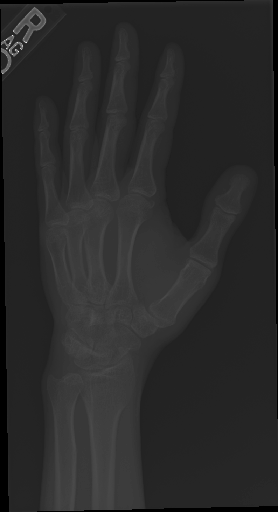

In [18]:
cv2_imshow(imgs_originais[1])

Imagem 3: "analise da imagem 3"

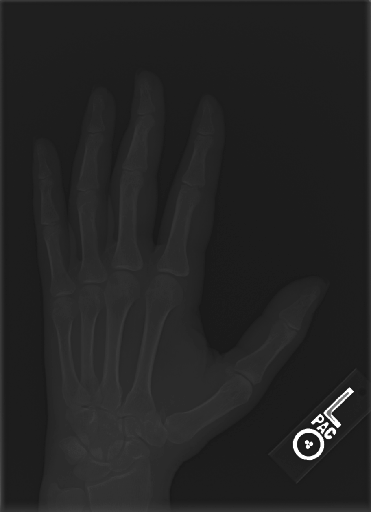

In [19]:
cv2_imshow(imgs_originais[2])

Insersão de Ruído Sal e Pimenta

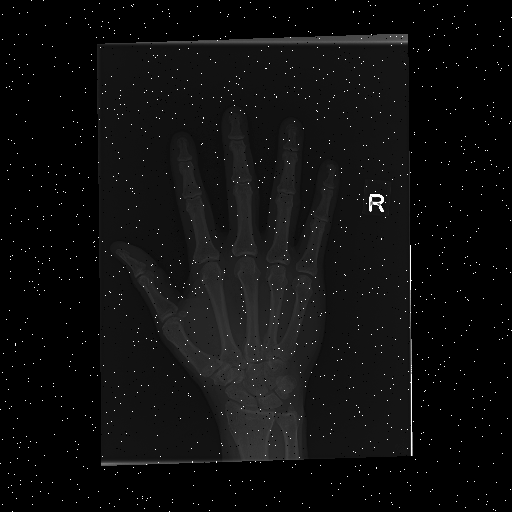

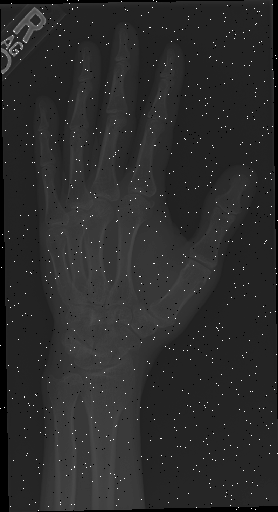

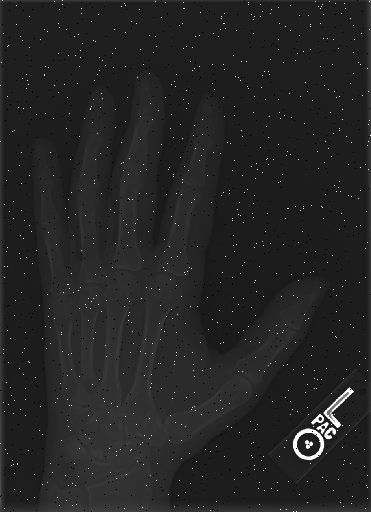

In [21]:
prob_ruido = 0.01  # 1% dos pixels afetados

imgs_ruidosas = []

for img in imgs_originais:
    img_ruidosa = img.copy()
    h, w = img_ruidosa.shape

    mascara = np.random.rand(h, w)
    img_ruidosa[mascara < prob_ruido / 2] = 0
    img_ruidosa[mascara > 1 - prob_ruido / 2] = 255

    imgs_ruidosas.append(img_ruidosa)

for img in imgs_ruidosas:
    cv2_imshow(img)

Pipeline 01 - Equalização de Histograma (OP) -> Filtro da Mediana (Suavização) -> High-Boost (Aguçamento)

Operação pontual — Equalização de Histograma

Histograma -> CDF -> LUT -> aplicação pixel a pixel.

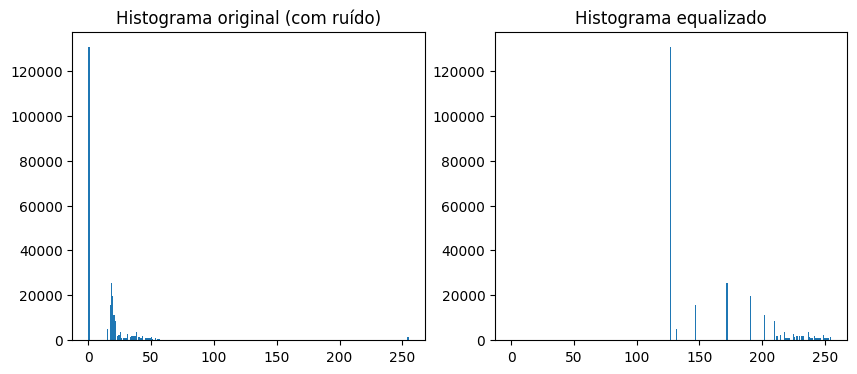

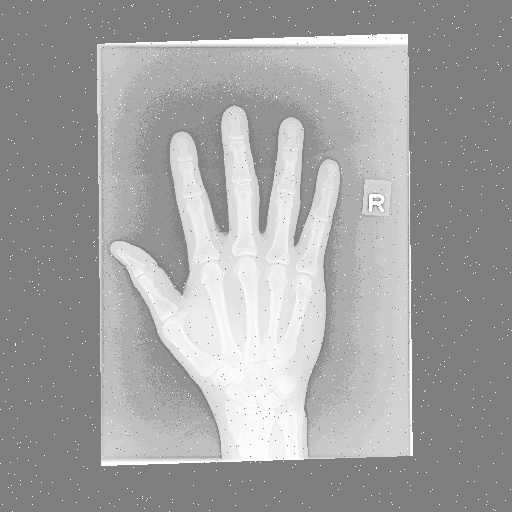

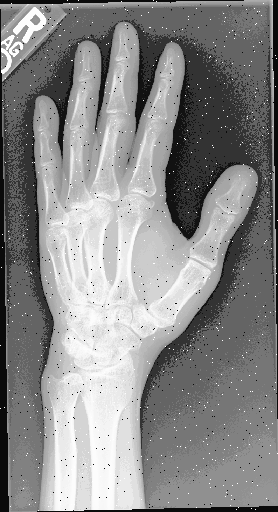

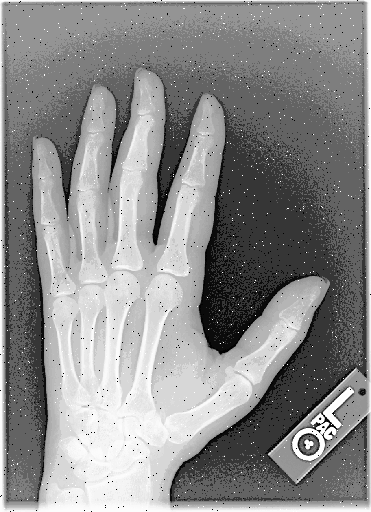

In [22]:
imgs_equalizadas_c1 = []

for img in imgs_ruidosas:
    histograma = np.zeros(256, dtype=np.int64)
    for v in range(256):
        histograma[v] = np.sum(img == v)

    cdf = np.cumsum(histograma)
    cdf_normalizada = cdf / cdf[-1]

    lut = np.round(cdf_normalizada * 255).astype(np.uint8)

    img_equalizada = lut[img]
    imgs_equalizadas_c1.append(img_equalizada)

# Exemplo: histograma antes x depois, para a primeira imagem
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
eixos[0].hist(imgs_ruidosas[0].ravel(), bins=256, range=(0, 255))
eixos[0].set_title('Histograma original (com ruído)')
eixos[1].hist(imgs_equalizadas_c1[0].ravel(), bins=256, range=(0, 255))
eixos[1].set_title('Histograma equalizado')
plt.show()

for img in imgs_equalizadas_c1:
    cv2_imshow(img)

Suavização — Filtro da Mediana

Filtro estatístico não-linear, adequado para ruído impulsivo (sal e pimenta).

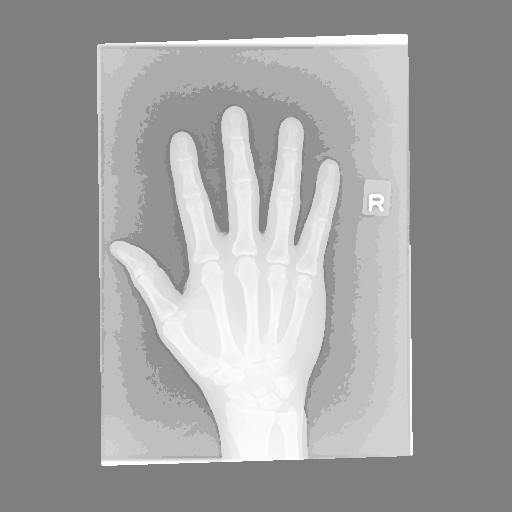

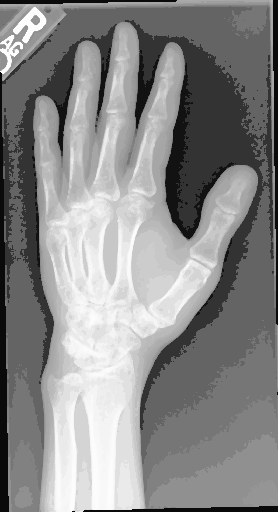

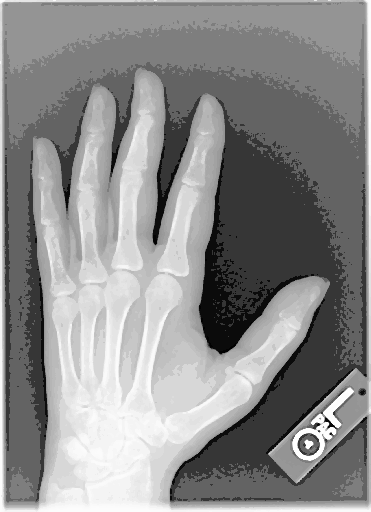

In [23]:
k_mediana = 3
raio = k_mediana // 2

imgs_suavizadas_c1 = []

for img in imgs_equalizadas_c1:
    h, w = img.shape
    img_padded = np.pad(img, raio, mode='reflect')
    img_suavizada = np.zeros_like(img)

    for i in range(h):
        for j in range(w):
            janela = img_padded[i:i + k_mediana, j:j + k_mediana]
            img_suavizada[i, j] = np.median(janela)

    imgs_suavizadas_c1.append(img_suavizada)

for img in imgs_suavizadas_c1:
    cv2_imshow(img)

Aguçamento — High-Boost Filtering (Unsharp Masking generalizado)

$g = f + k\cdot(f - \bar f)$, onde $\bar f$ é a imagem borrada (média 5x5) e $k$ controla a intensidade do realce ($k=1$: unsharp clássico; $k>1$: highboost).

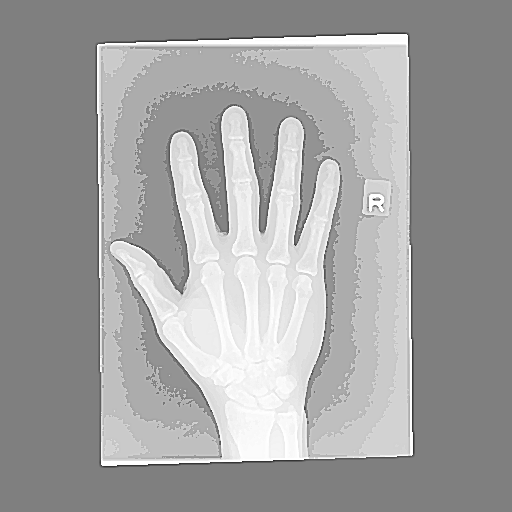

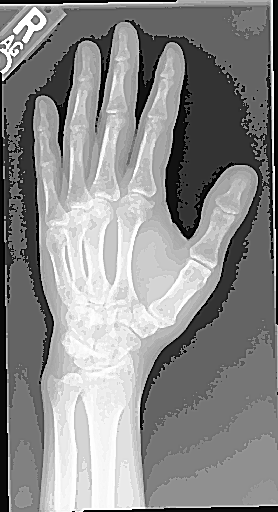

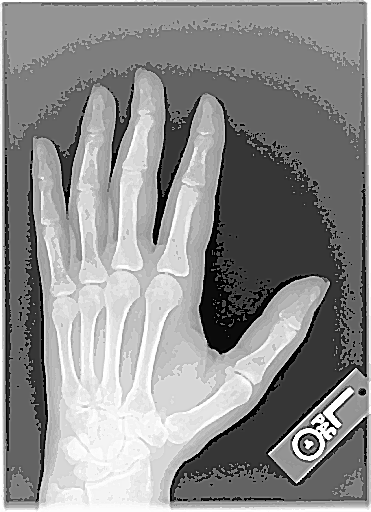

In [24]:
k_blur = 5
raio_blur = k_blur // 2
k_boost = 1.5

imgs_final_c1 = []

for img in imgs_suavizadas_c1:
    h, w = img.shape
    img_f = img.astype(np.float64)
    img_padded = np.pad(img_f, raio_blur, mode='reflect')

    img_borrada = np.zeros((h, w), dtype=np.float64)
    for i in range(h):
        for j in range(w):
            janela = img_padded[i:i + k_blur, j:j + k_blur]
            img_borrada[i, j] = np.mean(janela)

    mascara_unsharp = img_f - img_borrada
    img_realcada = img_f + k_boost * mascara_unsharp
    img_realcada = np.clip(img_realcada, 0, 255).astype(np.uint8)

    imgs_final_c1.append(img_realcada)

for img in imgs_final_c1:
    cv2_imshow(img)

Pipeline 02 - Filtro da Mediana (Suavização) -> Estiramento por Percentil (OP) -> High-Boost (Aguçamento)

A mediana remove o ruído impulsivo antes do contraste. A operação pontual deixa de ser a equalização global (que é dominada pelo fundo preto) e passa a ser um estiramento linear pelos percentis 1–99% só da região da placa; o fundo permanece 0. O high-boost usa $k$ mais baixo para não saturar os ossos.

Suavização — Filtro da Mediana

Aplicado diretamente sobre as imagens ruidosas (`k=3`).

In [ ]:
imgs_suavizadas_c2 = []

for img in imgs_ruidosas:
    h, w = img.shape
    img_padded = np.pad(img, raio, mode='reflect')
    img_suavizada = np.zeros_like(img)

    for i in range(h):
        for j in range(w):
            janela = img_padded[i:i + k_mediana, j:j + k_mediana]
            img_suavizada[i, j] = np.median(janela)

    imgs_suavizadas_c2.append(img_suavizada)

for img in imgs_suavizadas_c2:
    cv2_imshow(img)

Operação pontual — Estiramento de Contraste por Percentil

Máscara de fundo (`img > 8`): histograma da placa → percentis 1% e 99% → LUT linear para $[0, 255]$. Pixels de fundo ficam em 0, então o pico preto não empurra os ossos para o branco.

In [ ]:
limiar_fundo = 8
p_low = 1
p_high = 99

imgs_estiradas_c2 = []

for img in imgs_suavizadas_c2:
    mascara_placa = img > limiar_fundo

    if np.any(mascara_placa):
        valores = img[mascara_placa].astype(np.float64)
        lo = np.percentile(valores, p_low)
        hi = np.percentile(valores, p_high)
    else:
        lo, hi = 0.0, 255.0

    img_f = img.astype(np.float64)
    if hi > lo:
        img_estirada = (img_f - lo) * (255.0 / (hi - lo))
    else:
        img_estirada = img_f.copy()

    img_estirada = np.clip(img_estirada, 0, 255).astype(np.uint8)
    img_estirada[~mascara_placa] = 0
    imgs_estiradas_c2.append(img_estirada)

for img in imgs_estiradas_c2:
    cv2_imshow(img)

Aguçamento — High-Boost

Mesma janela de média da Pipeline 01 (`k_blur=5`), com $k$ menor (`k_boost=1.2`) porque o estiramento já recuperou contraste e um boost forte saturaria os ossos.

In [ ]:
k_boost_c2 = 1.2

imgs_final_c2 = []

for img in imgs_estiradas_c2:
    h, w = img.shape
    img_f = img.astype(np.float64)
    img_padded = np.pad(img_f, raio_blur, mode='reflect')

    img_borrada = np.zeros((h, w), dtype=np.float64)
    for i in range(h):
        for j in range(w):
            janela = img_padded[i:i + k_blur, j:j + k_blur]
            img_borrada[i, j] = np.mean(janela)

    mascara_unsharp = img_f - img_borrada
    img_realcada = img_f + k_boost_c2 * mascara_unsharp
    img_realcada = np.clip(img_realcada, 0, 255).astype(np.uint8)

    imgs_final_c2.append(img_realcada)

for img in imgs_final_c2:
    cv2_imshow(img)